# Within-family grouping validation: per-V-gene selection factor consistency

The entrenchment analysis pools all V genes within a family to compute a single median log selection factor per (site, parent_aa, target_aa). But V genes within a family differ at 10-15% of positions, so two V genes sharing the same amino acid at a site might have different selection landscapes.

**Approach**: For each (site, parent_aa, target_aa) combination, compute the median log_selection_factor *per V gene* instead of per family. Then assess agreement using:
1. **Individual V gene threshold agreement**: what fraction of individual V genes at entrenched combos also fall below -1?
2. **ICC (Intraclass Correlation Coefficient)**: fraction of total variance explained by substitution identity vs. V gene identity. ICC > 0.75 = excellent agreement.
3. **Pairwise V gene correlations**: for each pair of V genes, correlate their selection factors across shared substitutions.
4. **Strip plots at entrenched sites**: visual check that V genes cluster tightly.

---

## Summary of results

**The within-family grouping is well-justified.**

The most direct test: **92-94% of individual V gene medians at entrenched combos independently fall below the -1 threshold** (IGHV1: 94%, IGHV3: 93%, IGHV4: 92%). All combos in all three families have majority agreement. This means pooling rarely creates false entrenchment calls — the vast majority of individual V genes agree with the family-level classification.

ICC values of 0.973 (IGHV1), 0.961 (IGHV3), and 0.981 (IGHV4) indicate that 96-98% of variance in per-V-gene median log selection factors is explained by substitution identity, not V gene identity. The between-group (substitution) mean squares exceed the within-group (V gene disagreement) mean squares by 470-660x.

Pairwise V gene correlations are uniformly high (median r = 0.97, 100% of pairs > 0.9), though this is partly driven by the wide dynamic range across substitutions.

34 outlier V gene/site/substitution combinations were identified (|z| > 2). Outlier V genes are not systematically more sequence-divergent from their family (Mann-Whitney U: IGHV1 p=0.19, IGHV3 p=0.03, IGHV4 p=0.46). This suggests outliers reflect sampling noise or gene-specific idiosyncrasies at particular sites, not a systematic problem with the grouping assumption.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from utils import load_and_process_dasm_data, GERMLINE_PATH_DICTIONARY, sort_antibody_sites, load_entrenched_sites
from netam.sequences import AA_STR_SORTED

model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"
dataset_name = "v1rodriguez"
numbering_scheme = 'chothia'

germline_codons_df = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})
site_sub_probs_df, pcp_df, aa_site_subs_selection_df_germline = load_and_process_dasm_data(
    model_name=model_name, dataset_name=dataset_name,
    numbering_scheme=numbering_scheme, figures_dir="figures")

PALETTE_AA = dict(zip(AA_STR_SORTED, sns.color_palette('tab20', len(AA_STR_SORTED))))
figures_dir = 'figures'
os.makedirs(figures_dir, exist_ok=True)

Adding one_mutation_away column (vectorized)...


In [2]:
def compute_per_vgene_medians(aa_site_subs_selection_df_germline, v_family,
                               one_mutation_away=True, limit_pcp_depth=True,
                               remove_rare_aas=True, min_count=3):
    """
    Compute per-V-gene median log selection factors within a V family.
    
    Groups by ['v_gene', 'v_family', 'site', 'parent_aa', 'selection_factor_target_aa']
    instead of ['v_family', ...] to get one median per V gene.
    """
    df = aa_site_subs_selection_df_germline[aa_site_subs_selection_df_germline.v_family == v_family].copy()

    if limit_pcp_depth:
        df = df[df.depth == 2]
    if one_mutation_away:
        df = df[df['one_mutation_away'] == True]
    df = df[df.is_germline_codon == True]
    df = df.dropna(subset=['log_selection_factor'])

    if remove_rare_aas:
        counts = (df[['v_gene', 'site', 'parent_aa', 'pcp_index']]
                  .drop_duplicates()
                  .groupby(['v_gene', 'site', 'parent_aa'])
                  .size()
                  .reset_index(name='count'))
        counts = counts[counts['count'] >= min_count]
        df = pd.merge(df, counts[['v_gene', 'site', 'parent_aa']],
                       on=['v_gene', 'site', 'parent_aa'], how='inner')

    per_vgene = (df.groupby(['v_gene', 'v_family', 'site', 'parent_aa',
                              'selection_factor_target_aa'])
                  .agg(
                      log_selection_factor=('log_selection_factor', 'median'),
                      n_observations=('pcp_index', 'nunique')
                  )
                  .reset_index())

    return per_vgene

In [3]:
# Load entrenched sites
entrenched_sites, entrenched_sites_aas, pairwise_df_dict, site_color_map, within_dfs, vs_dfs = \
    load_entrenched_sites(numbering_scheme=numbering_scheme)

v_families_to_analyze = ['IGHV1', 'IGHV3', 'IGHV4']

# Compute per-V-gene medians for each family (all sites)
per_vgene_all = []
for v_fam in v_families_to_analyze:
    per_vgene = compute_per_vgene_medians(
        aa_site_subs_selection_df_germline, v_fam,
        one_mutation_away=True, limit_pcp_depth=True,
        remove_rare_aas=True, min_count=3
    )
    per_vgene_all.append(per_vgene)
    print(f"{v_fam}: {len(per_vgene)} per-V-gene medians across "
          f"{per_vgene.v_gene.nunique()} V genes")

per_vgene_all_df = pd.concat(per_vgene_all, ignore_index=True)

# Combine within-family and between-family entrenched sites
all_entrenched = pd.concat([within_dfs, vs_dfs], ignore_index=True).drop_duplicates()
all_entrenched = all_entrenched.rename(columns={
    'amino_acid': 'parent_aa',
    'target_amino_acid': 'selection_factor_target_aa'
})
entrenched_keys = all_entrenched[['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']].drop_duplicates()
entrenched_keys['is_entrenched'] = True

# Also keep track of within-only vs between-only for separate reporting
within_keys = within_dfs.rename(columns={
    'amino_acid': 'parent_aa', 'target_amino_acid': 'selection_factor_target_aa'
})[['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']].drop_duplicates()
within_keys['is_entrenched_within'] = True

vs_keys = vs_dfs.rename(columns={
    'amino_acid': 'parent_aa', 'target_amino_acid': 'selection_factor_target_aa'
})[['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']].drop_duplicates()
vs_keys['is_entrenched_between'] = True

per_vgene_all_df = pd.merge(per_vgene_all_df, entrenched_keys,
    on=['v_family', 'site', 'parent_aa', 'selection_factor_target_aa'], how='left')
per_vgene_all_df = pd.merge(per_vgene_all_df, within_keys,
    on=['v_family', 'site', 'parent_aa', 'selection_factor_target_aa'], how='left')
per_vgene_all_df = pd.merge(per_vgene_all_df, vs_keys,
    on=['v_family', 'site', 'parent_aa', 'selection_factor_target_aa'], how='left')

for col in ['is_entrenched', 'is_entrenched_within', 'is_entrenched_between']:
    per_vgene_all_df[col] = per_vgene_all_df[col].fillna(False).astype(bool)

print(f"Total per-V-gene medians: {len(per_vgene_all_df)}")
print(f"  Entrenched (any): {per_vgene_all_df['is_entrenched'].sum()}")
print(f"    Within-family:  {per_vgene_all_df['is_entrenched_within'].sum()}")
print(f"    Between-family: {per_vgene_all_df['is_entrenched_between'].sum()}")
print(f"  Non-entrenched:   {(~per_vgene_all_df['is_entrenched']).sum()}")
for v_fam in v_families_to_analyze:
    subset = per_vgene_all_df[per_vgene_all_df.v_family == v_fam]
    n_ent = subset['is_entrenched'].sum()
    n_within = subset['is_entrenched_within'].sum()
    n_between = subset['is_entrenched_between'].sum()
    n_combos_ent = subset[subset.is_entrenched].groupby(
        ['site', 'parent_aa', 'selection_factor_target_aa']).ngroups if n_ent > 0 else 0
    print(f"  {v_fam}: {n_ent} entrenched ({n_combos_ent} combos: "
          f"{n_within} within, {n_between} between)")

IGHV1: 12428 per-V-gene medians across 22 V genes


IGHV3: 27835 per-V-gene medians across 50 V genes


IGHV4: 8455 per-V-gene medians across 15 V genes
Total per-V-gene medians: 48718
  Entrenched (any): 836
    Within-family:  240
    Between-family: 702
  Non-entrenched:   47882
  IGHV1: 218 entrenched (30 combos: 70 within, 187 between)
  IGHV3: 493 entrenched (36 combos: 150 within, 392 between)
  IGHV4: 125 entrenched (17 combos: 20 within, 123 between)


/loc/scratch/49522974/ipykernel_8167/4151655352.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  per_vgene_all_df[col] = per_vgene_all_df[col].fillna(False).astype(bool)
/loc/scratch/49522974/ipykernel_8167/4151655352.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  per_vgene_all_df[col] = per_vgene_all_df[col].fillna(False).astype(bool)
/loc/scratch/49522974/ipykernel_8167/4151655352.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=F

In [4]:
def compute_icc(per_vgene_df, v_family):
    """
    Compute one-way random effects ICC for a V family across ALL sites.
    
    - Groups: each unique (site, parent_aa, target_aa) combination
    - Observations within a group: the per-V-gene median log_selection_factor
      from each V gene that has that parent_aa at that site
    
    Between-group variance: how much the group means differ from each other
      (e.g., site 33 A>D has mean -2.8, site 50 Y>S has mean -1.5, etc.)
    Within-group variance: how much V genes disagree within the same group
      (e.g., for site 33 A>D, IGHV3-30 gives -3.0 and IGHV3-73 gives -1.1)
    
    ICC = (MS_between - MS_within) / (MS_between + (k0 - 1) * MS_within)
    """
    df = per_vgene_df[per_vgene_df.v_family == v_family].copy()
    
    df['group'] = df['site'] + '_' + df['parent_aa'] + '_' + df['selection_factor_target_aa']
    
    # Filter to groups with >= 2 V genes
    group_sizes = df.groupby('group').size()
    valid_groups = group_sizes[group_sizes >= 2].index
    df = df[df['group'].isin(valid_groups)]
    
    if len(valid_groups) < 2:
        return None
    
    grand_mean = df['log_selection_factor'].mean()
    k_groups = len(valid_groups)
    N = len(df)
    
    group_means = df.groupby('group')['log_selection_factor'].mean()
    group_ns = df.groupby('group').size()
    
    SS_between = sum(group_ns[g] * (group_means[g] - grand_mean)**2 for g in valid_groups)
    SS_within = sum(
        ((df[df['group'] == g]['log_selection_factor'] - group_means[g])**2).sum()
        for g in valid_groups
    )
    
    MS_between = SS_between / (k_groups - 1)
    MS_within = SS_within / (N - k_groups)
    
    k0 = (1 / (k_groups - 1)) * (N - sum(group_ns**2) / N)
    
    icc = (MS_between - MS_within) / (MS_between + (k0 - 1) * MS_within)
    
    # Also compute the within-group std at entrenched vs non-entrenched groups
    group_stats = df.groupby('group').agg(
        mean_lsf=('log_selection_factor', 'mean'),
        std_lsf=('log_selection_factor', 'std'),
        n_vgenes=('log_selection_factor', 'size'),
        is_entrenched=('is_entrenched', 'first'),
    ).reset_index()
    
    return {
        'v_family': v_family,
        'icc': icc,
        'n_groups': k_groups,
        'n_observations': N,
        'mean_group_size': N / k_groups,
        'MS_between': MS_between,
        'MS_within': MS_within,
        'grand_mean': grand_mean,
        'group_stats': group_stats,
    }


print("=== ICC: Intraclass Correlation Coefficient ===")
print("Computed on ALL (site, parent_aa, target_aa) groups within each V family.")
print("Groups = substitution combos. Observations = per-V-gene medians.\n")
print("Between-group variance = how much substitutions differ from each other")
print("Within-group variance = how much V genes disagree about the SAME substitution\n")

icc_results = {}
for v_fam in v_families_to_analyze:
    result = compute_icc(per_vgene_all_df, v_fam)
    icc_results[v_fam] = result
    
    print(f"{v_fam}: ICC = {result['icc']:.3f}")
    print(f"  {result['n_groups']} groups, {result['n_observations']} observations, "
          f"mean group size {result['mean_group_size']:.1f}")
    print(f"  Grand mean of all per-V-gene medians: {result['grand_mean']:.3f}")
    print(f"  MS_between (substitution differences): {result['MS_between']:.3f}")
    print(f"  MS_within (V gene disagreement):       {result['MS_within']:.3f}")
    print(f"  Ratio MS_between/MS_within:            {result['MS_between']/result['MS_within']:.1f}x")
    
    # Report within-group std for entrenched vs non-entrenched groups
    gs = result['group_stats']
    for is_ent, label in [(True, 'entrenched'), (False, 'non-entrenched')]:
        sub = gs[gs.is_entrenched == is_ent]
        if len(sub) > 0:
            median_std = sub['std_lsf'].dropna().median()
            median_mean = sub['mean_lsf'].median()
            print(f"  {label} groups ({len(sub)}): "
                  f"median within-group std = {median_std:.3f}, "
                  f"median group mean = {median_mean:.3f}")
    print()

=== ICC: Intraclass Correlation Coefficient ===
Computed on ALL (site, parent_aa, target_aa) groups within each V family.
Groups = substitution combos. Observations = per-V-gene medians.

Between-group variance = how much substitutions differ from each other
Within-group variance = how much V genes disagree about the SAME substitution



IGHV1: ICC = 0.973
  938 groups, 12222 observations, mean group size 13.0
  Grand mean of all per-V-gene medians: -1.726
  MS_between (substitution differences): 70.144
  MS_within (V gene disagreement):       0.148
  Ratio MS_between/MS_within:            473.2x
  entrenched groups (28): median within-group std = 0.233, median group mean = -1.799
  non-entrenched groups (910): median within-group std = 0.254, median group mean = -0.807



IGHV3: ICC = 0.961
  1146 groups, 27652 observations, mean group size 24.1
  Grand mean of all per-V-gene medians: -1.900
  MS_between (substitution differences): 127.398
  MS_within (V gene disagreement):       0.215
  Ratio MS_between/MS_within:            593.3x
  entrenched groups (29): median within-group std = 0.391, median group mean = -1.913
  non-entrenched groups (1117): median within-group std = 0.314, median group mean = -0.947



IGHV4: ICC = 0.981
  660 groups, 8320 observations, mean group size 12.6
  Grand mean of all per-V-gene medians: -1.645
  MS_between (substitution differences): 62.760
  MS_within (V gene disagreement):       0.095
  Ratio MS_between/MS_within:            660.4x
  entrenched groups (12): median within-group std = 0.184, median group mean = -1.558
  non-entrenched groups (648): median within-group std = 0.223, median group mean = -1.038



In [5]:
threshold = -1

print("=== Fraction of individual V genes agreeing with entrenchment call ===")
print(f"Threshold: {threshold:.3f}")
print("For each entrenched (site, parent_aa, target_aa), what fraction of")
print("individual V gene medians also fall below the threshold?\n")

for v_fam in v_families_to_analyze:
    df = per_vgene_all_df[(per_vgene_all_df.v_family == v_fam) & 
                           (per_vgene_all_df.is_entrenched)].copy()
    if len(df) == 0:
        continue
    
    n_below = (df['log_selection_factor'] < threshold).sum()
    n_total = len(df)
    frac_below = n_below / n_total
    
    # Per-combo breakdown
    combo_fracs = []
    for (site, paa, taa), group in df.groupby(['site', 'parent_aa', 'selection_factor_target_aa']):
        n = len(group)
        n_b = (group['log_selection_factor'] < threshold).sum()
        combo_fracs.append({
            'site': site, 'parent_aa': paa, 'target_aa': taa,
            'n_vgenes': n, 'n_below': n_b, 'frac_below': n_b / n,
        })
    combo_fracs_df = pd.DataFrame(combo_fracs)
    
    n_unanimous = (combo_fracs_df['frac_below'] == 1.0).sum()
    n_majority = (combo_fracs_df['frac_below'] >= 0.5).sum()
    n_combos = len(combo_fracs_df)
    
    print(f"{v_fam}: {n_below}/{n_total} ({frac_below:.1%}) individual V gene medians below threshold")
    print(f"  {n_unanimous}/{n_combos} combos have 100% of V genes below threshold")
    print(f"  {n_majority}/{n_combos} combos have majority (>=50%) below threshold")
    
    # Show combos where agreement is weakest
    weak = combo_fracs_df[combo_fracs_df['frac_below'] < 1.0].sort_values('frac_below')
    if len(weak) > 0:
        print(f"  Combos with <100% agreement:")
        for _, row in weak.iterrows():
            print(f"    {row['site']} {row['parent_aa']}>{row['target_aa']}: "
                  f"{row['n_below']}/{row['n_vgenes']} ({row['frac_below']:.0%})")
    print()

=== Fraction of individual V genes agreeing with entrenchment call ===
Threshold: -1.000
For each entrenched (site, parent_aa, target_aa), what fraction of
individual V gene medians also fall below the threshold?

IGHV1: 206/218 (94.5%) individual V gene medians below threshold
  27/30 combos have 100% of V genes below threshold
  30/30 combos have majority (>=50%) below threshold
  Combos with <100% agreement:
    9 A>G: 13/21 (62%)
    50 W>R: 6/9 (67%)
    33 A>D: 9/10 (90%)

IGHV3: 459/493 (93.1%) individual V gene medians below threshold
  22/36 combos have 100% of V genes below threshold
  36/36 combos have majority (>=50%) below threshold
  Combos with <100% agreement:
    50 S>Y: 1/2 (50%)
    94 T>R: 1/2 (50%)
    52 R>G: 5/7 (71%)
    35 N>D: 5/7 (71%)
    33 A>G: 14/18 (78%)
    52 R>S: 5/6 (83%)
    67 F>V: 42/50 (84%)
    50 Y>S: 7/8 (88%)
    73 N>K: 36/41 (88%)
    53 D>Y: 15/17 (88%)
    33 A>D: 16/18 (89%)
    33 Y>S: 9/10 (90%)
    52 S>R: 18/20 (90%)
    29 F>V: 42/4

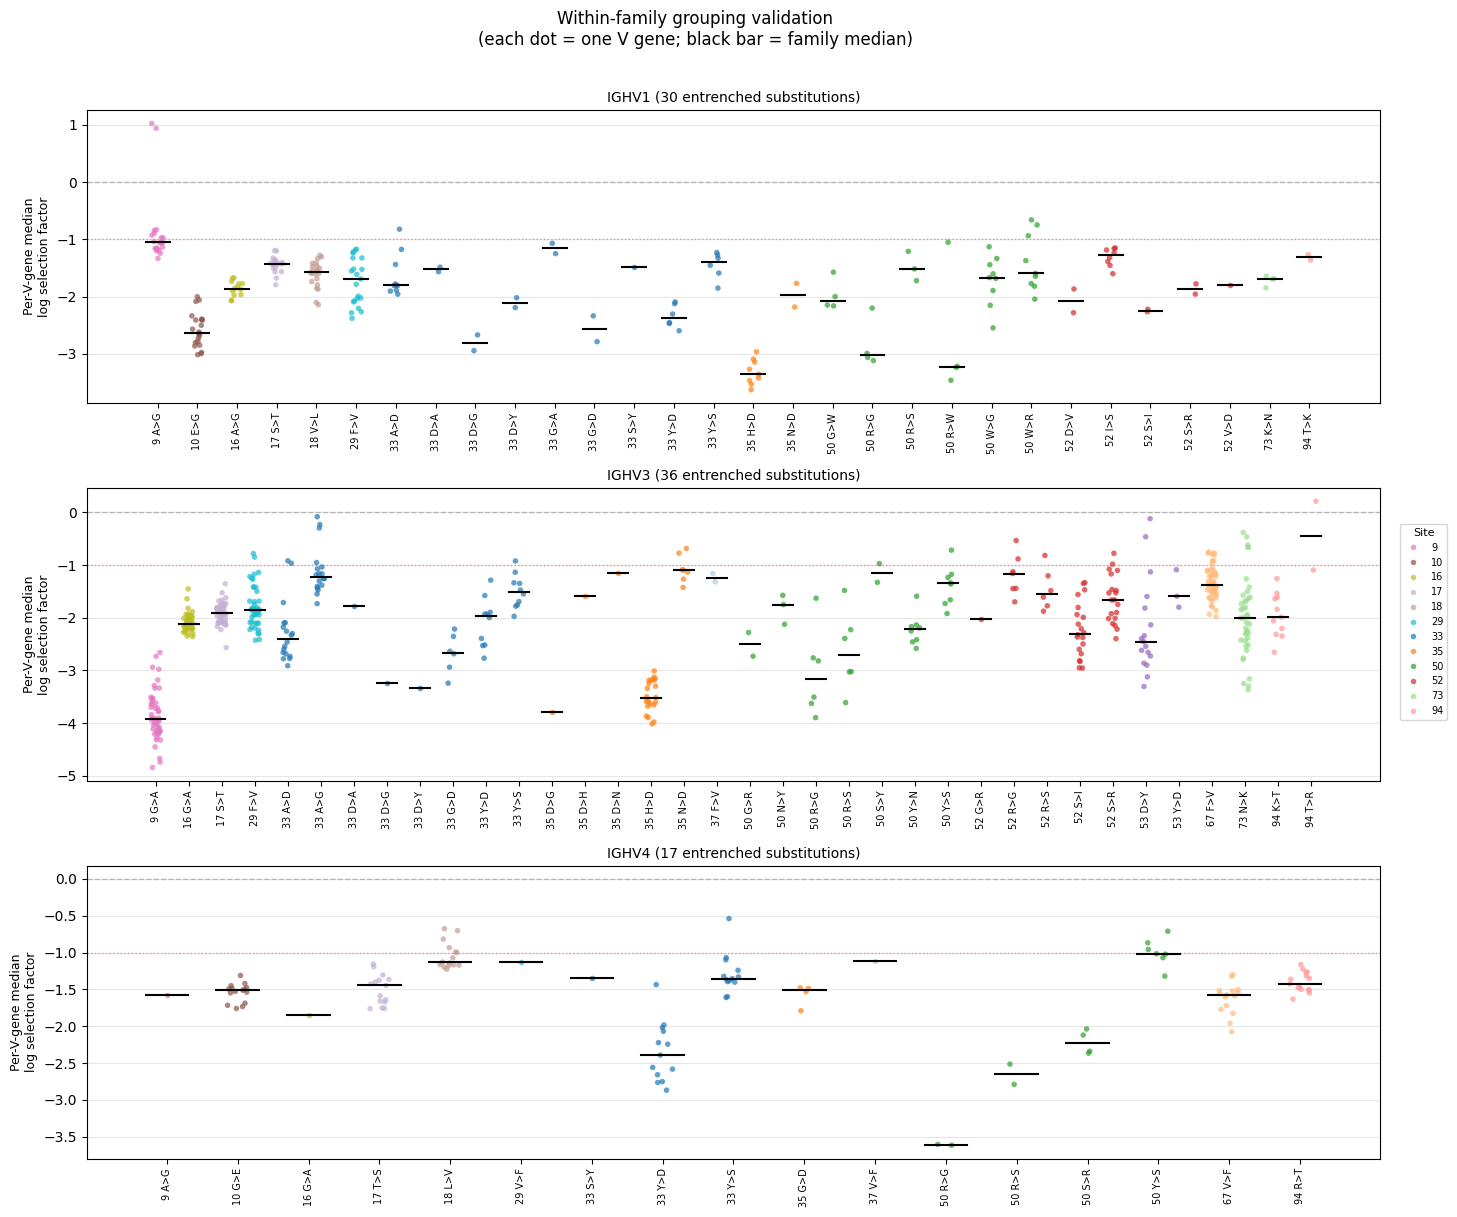

In [6]:
def plot_per_vgene_strip(per_vgene_df, v_family, site_color_map=None, ax=None):
    """
    Strip plot of per-V-gene medians for each entrenched substitution within a V family.
    Each dot is one V gene's median. Colored by site.
    """
    df = per_vgene_df[(per_vgene_df.v_family == v_family) & (per_vgene_df.is_entrenched)].copy()
    if len(df) == 0:
        print(f"No entrenched data for {v_family}")
        return None

    df['combo_label'] = (df['site'].astype(str) + ' ' +
                          df['parent_aa'] + '>' + df['selection_factor_target_aa'])

    sorted_sites = sort_antibody_sites(df['site'].unique())
    site_order = {s: i for i, s in enumerate(sorted_sites)}
    df['site_order'] = df['site'].map(site_order)
    df = df.sort_values(['site_order', 'parent_aa', 'selection_factor_target_aa'])
    combo_order = list(dict.fromkeys(df['combo_label']))

    sns.stripplot(data=df, x='combo_label', y='log_selection_factor',
                  hue='site', palette=site_color_map,
                  order=combo_order, dodge=False,
                  jitter=0.15, size=4, alpha=0.7, ax=ax)

    # Add family-level median as horizontal bars
    combo_medians = df.groupby('combo_label')['log_selection_factor'].median()
    for i, combo in enumerate(combo_order):
        if combo in combo_medians.index:
            median_val = combo_medians[combo]
            ax.plot([i - 0.3, i + 0.3], [median_val, median_val],
                    color='black', linewidth=1.5, zorder=5)

    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(y=-1, color='red', linestyle=':', alpha=0.4, linewidth=1,
               label='threshold = -1')

    ax.set_xlabel('')
    ax.set_ylabel('Per-V-gene median\nlog selection factor', fontsize=9)
    ax.set_title(f'{v_family} ({len(combo_order)} entrenched substitutions)', fontsize=10)

    ax.set_xticks(range(len(combo_order)))
    ax.set_xticklabels(combo_order, rotation=90, ha='center', fontsize=7)

    ax.get_legend().remove()
    ax.grid(True, alpha=0.3, axis='y')

    return combo_order


fig, axes = plt.subplots(3, 1, figsize=(14, 12))

all_combo_orders = {}
for i, v_fam in enumerate(v_families_to_analyze):
    combo_order = plot_per_vgene_strip(per_vgene_all_df, v_fam,
                                        site_color_map=site_color_map, ax=axes[i])
    all_combo_orders[v_fam] = combo_order

# Add a single shared legend for sites
handles, labels = axes[0].get_legend_handles_labels()
# Filter to just site labels (exclude threshold line)
site_handles = [h for h, l in zip(handles, labels) if l != 'threshold = -1']
site_labels = [l for l in labels if l != 'threshold = -1']
fig.legend(site_handles, site_labels, bbox_to_anchor=(1.0, 0.5), loc='center left',
           title='Site', fontsize=7, title_fontsize=8, ncol=1)

fig.suptitle('Within-family grouping validation\n'
             '(each dot = one V gene; black bar = family median)',
             fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(f'{figures_dir}/within_family_validation_strip.png',
            dpi=300, bbox_inches='tight')
plt.show()

IGHV1: 231 V gene pairs with >= 5 shared substitutions, median r = 0.979


IGHV3: 1225 V gene pairs with >= 5 shared substitutions, median r = 0.968
IGHV4: 105 V gene pairs with >= 5 shared substitutions, median r = 0.983


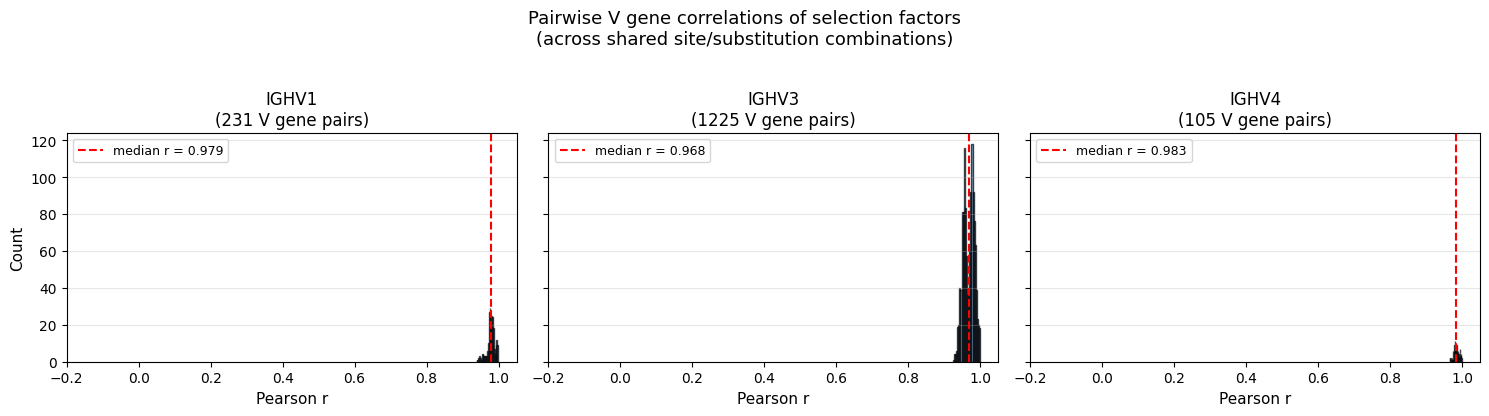


Overall: 1561 pairs, median r = 0.973, mean r = 0.970, fraction with r > 0.9: 100.0%


In [7]:
def compute_pairwise_vgene_correlations(per_vgene_df, v_family):
    """
    For each pair of V genes in a family, correlate their per-V-gene median
    log selection factors across shared (site, parent_aa, target_aa) combinations.
    """
    df = per_vgene_df[per_vgene_df.v_family == v_family].copy()
    df['combo'] = df['site'] + '_' + df['parent_aa'] + '_' + df['selection_factor_target_aa']

    # Pivot: rows = combos, columns = v_genes, values = log_selection_factor
    pivot = df.pivot_table(index='combo', columns='v_gene',
                            values='log_selection_factor', aggfunc='first')

    v_genes = pivot.columns.tolist()
    records = []
    for i in range(len(v_genes)):
        for j in range(i + 1, len(v_genes)):
            vg1, vg2 = v_genes[i], v_genes[j]
            paired = pivot[[vg1, vg2]].dropna()
            n_shared = len(paired)
            if n_shared < 5:
                continue
            r, p = stats.pearsonr(paired[vg1], paired[vg2])
            records.append({
                'v_family': v_family,
                'v_gene_1': vg1,
                'v_gene_2': vg2,
                'pearson_r': r,
                'p_value': p,
                'n_shared_combos': n_shared,
            })

    return pd.DataFrame(records)


# Compute pairwise correlations for each family
all_pairwise = []
for v_fam in v_families_to_analyze:
    pw = compute_pairwise_vgene_correlations(per_vgene_all_df, v_fam)
    all_pairwise.append(pw)
    print(f"{v_fam}: {len(pw)} V gene pairs with >= 5 shared substitutions, "
          f"median r = {pw['pearson_r'].median():.3f}")

all_pairwise_df = pd.concat(all_pairwise, ignore_index=True)

# Plot: distribution of pairwise correlations per family
fig, axes = plt.subplots(1, len(v_families_to_analyze), figsize=(5 * len(v_families_to_analyze), 4),
                          sharey=True)
for i, v_fam in enumerate(v_families_to_analyze):
    ax = axes[i]
    subset = all_pairwise_df[all_pairwise_df.v_family == v_fam]
    ax.hist(subset['pearson_r'], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(x=subset['pearson_r'].median(), color='red', linestyle='--',
               label=f"median r = {subset['pearson_r'].median():.3f}")
    ax.set_xlabel('Pearson r', fontsize=11)
    ax.set_title(f'{v_fam}\n({len(subset)} V gene pairs)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(-0.2, 1.05)

axes[0].set_ylabel('Count', fontsize=11)
fig.suptitle('Pairwise V gene correlations of selection factors\n'
             '(across shared site/substitution combinations)',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print(f"\nOverall: {len(all_pairwise_df)} pairs, "
      f"median r = {all_pairwise_df['pearson_r'].median():.3f}, "
      f"mean r = {all_pairwise_df['pearson_r'].mean():.3f}, "
      f"fraction with r > 0.9: {(all_pairwise_df['pearson_r'] > 0.9).mean():.1%}")

In [8]:
def identify_outlier_vgenes(per_vgene_df, z_threshold=2.0):
    """
    Identify V genes whose per-V-gene median deviates substantially
    from the family median at entrenched sites.
    """
    entrenched_df = per_vgene_df[per_vgene_df.is_entrenched].copy()
    outliers = []

    for (v_fam, site, parent_aa, target_aa), group in entrenched_df.groupby(
        ['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']):

        values = group['log_selection_factor'].values
        if len(values) < 3:
            continue

        family_median = np.median(values)
        within_std = np.std(values, ddof=1)
        if within_std < 0.01:
            continue

        for _, row in group.iterrows():
            z = (row['log_selection_factor'] - family_median) / within_std
            if abs(z) > z_threshold:
                outliers.append({
                    'v_family': v_fam,
                    'v_gene': row['v_gene'],
                    'site': site,
                    'parent_aa': parent_aa,
                    'target_aa': target_aa,
                    'vgene_median': row['log_selection_factor'],
                    'family_median': family_median,
                    'z_score': z,
                    'n_observations': row['n_observations'],
                })

    if not outliers:
        print(f"No outlier V genes found (|z| > {z_threshold})")
        return pd.DataFrame()
    return pd.DataFrame(outliers).sort_values('z_score', ascending=False)

outlier_vgenes = identify_outlier_vgenes(per_vgene_all_df, z_threshold=2.0)
print(f"Found {len(outlier_vgenes)} outlier V gene/site/substitution combinations (|z| > 2)")
if len(outlier_vgenes) > 0:
    display(outlier_vgenes)

Found 34 outlier V gene/site/substitution combinations (|z| > 2)


,v_family,v_gene,site,parent_aa,target_aa,vgene_median,family_median,z_score,n_observations
9,IGHV3,IGHV3-30*02,16,G,A,-1.453781,-2.113503,3.590459,37
8,IGHV1,IGHV1-18*04,9,A,G,1.026230,-1.052731,3.294868,61
7,IGHV1,IGHV1-18*01,9,A,G,0.942035,-1.052731,3.161430,266
32,IGHV4,IGHV4-34*01,33,Y,S,-0.538601,-1.353395,2.984416,310
12,IGHV3,IGHV3-43D*03,17,S,T,-1.354582,-1.908133,2.767332,7
13,IGHV3,IGHV3-15*07,29,F,V,-0.781606,-1.854342,2.701199,8
28,IGHV3,IGHV3-64*01,9,G,A,-2.658873,-3.914016,2.655223,19
4,IGHV1,IGHV1-69*13,33,A,D,-0.821847,-1.804744,2.624310,13
22,IGHV3,IGHV3-15*07,53,D,Y,-0.120414,-2.453508,2.598482,6
10,IGHV3,IGHV3-43D*03,16,G,A,-1.639695,-2.113503,2.578643,7


In [9]:
def compute_sequence_distances(germline_codons_df, v_family):
    """
    Compute pairwise amino acid sequence identity between all V genes in a family.
    Returns a DataFrame of pairwise distances.
    """
    family_df = germline_codons_df[germline_codons_df.v_family == v_family]
    pivot = family_df.pivot_table(index='v_gene', columns='site', 
                                   values='amino_acid', aggfunc='first')
    
    v_genes = pivot.index.tolist()
    records = []
    for i in range(len(v_genes)):
        for j in range(i + 1, len(v_genes)):
            vg1, vg2 = v_genes[i], v_genes[j]
            seq1 = pivot.loc[vg1]
            seq2 = pivot.loc[vg2]
            # Only compare sites present in both
            shared = seq1.dropna().index.intersection(seq2.dropna().index)
            if len(shared) == 0:
                continue
            matches = (seq1[shared] == seq2[shared]).sum()
            identity = matches / len(shared)
            records.append({
                'v_gene_1': vg1, 'v_gene_2': vg2,
                'aa_identity': identity,
                'n_differences': len(shared) - matches,
                'n_shared_sites': len(shared),
            })
    return pd.DataFrame(records)


if len(outlier_vgenes) > 0:
    outlier_v_genes_unique = outlier_vgenes[['v_family', 'v_gene']].drop_duplicates()
    
    print("=== Are outlier V genes more divergent from family consensus? ===\n")
    
    for v_fam in outlier_v_genes_unique['v_family'].unique():
        dist_df = compute_sequence_distances(germline_codons_df, v_fam)
        
        outlier_genes = set(outlier_v_genes_unique[
            outlier_v_genes_unique.v_family == v_fam]['v_gene'])
        all_genes = set(dist_df['v_gene_1'].unique()) | set(dist_df['v_gene_2'].unique())
        non_outlier_genes = all_genes - outlier_genes
        
        # For each V gene, compute mean identity to all other V genes in the family
        gene_mean_identity = {}
        for vg in all_genes:
            dists = dist_df[(dist_df.v_gene_1 == vg) | (dist_df.v_gene_2 == vg)]
            gene_mean_identity[vg] = dists['aa_identity'].mean()
        
        print(f"{v_fam}:")
        print(f"  Outlier V genes and their mean AA identity to family:")
        for vg in sorted(outlier_genes):
            identity = gene_mean_identity.get(vg, float('nan'))
            print(f"    {vg}: {identity:.3f}")
        
        non_outlier_identities = [gene_mean_identity[vg] for vg in non_outlier_genes 
                                   if vg in gene_mean_identity]
        outlier_identities = [gene_mean_identity[vg] for vg in outlier_genes 
                               if vg in gene_mean_identity]
        
        if non_outlier_identities:
            print(f"  Non-outlier mean identity to family: "
                  f"{np.mean(non_outlier_identities):.3f} "
                  f"(range {np.min(non_outlier_identities):.3f}-{np.max(non_outlier_identities):.3f})")
            print(f"  Outlier mean identity to family:     "
                  f"{np.mean(outlier_identities):.3f} "
                  f"(range {np.min(outlier_identities):.3f}-{np.max(outlier_identities):.3f})")
            
            # Mann-Whitney U test: are outlier V genes more divergent?
            if len(outlier_identities) >= 2 and len(non_outlier_identities) >= 2:
                u_stat, u_pval = stats.mannwhitneyu(
                    outlier_identities, non_outlier_identities, alternative='less')
                print(f"  Mann-Whitney U test (outliers more divergent?): "
                      f"p = {u_pval:.4f}")
        print()

=== Are outlier V genes more divergent from family consensus? ===



IGHV3:
  Outlier V genes and their mean AA identity to family:
    IGHV3-11*05: 0.829
    IGHV3-13*01: 0.812
    IGHV3-15*01: 0.774
    IGHV3-15*07: 0.773
    IGHV3-30*02: 0.834
    IGHV3-43*02: 0.835
    IGHV3-43D*03: 0.835
    IGHV3-49*04: 0.761
    IGHV3-53*02: 0.839
    IGHV3-64*01: 0.840
    IGHV3-66*02: 0.859
    IGHV3-72*01: 0.782
    IGHV3-73*01: 0.761
    IGHV3-73*02: 0.761
    IGHV3-9*01: 0.826
  Non-outlier mean identity to family: 0.823 (range 0.666-0.866)
  Outlier mean identity to family:     0.808 (range 0.761-0.859)
  Mann-Whitney U test (outliers more divergent?): p = 0.0271



IGHV1:
  Outlier V genes and their mean AA identity to family:
    IGHV1-18*01: 0.832
    IGHV1-18*04: 0.832
    IGHV1-69*04: 0.865
    IGHV1-69*13: 0.868
    IGHV1-69-2*01: 0.748
    IGHV1-8*01: 0.830
    IGHV1-8*03: 0.834
  Non-outlier mean identity to family: 0.839 (range 0.772-0.868)
  Outlier mean identity to family:     0.830 (range 0.748-0.868)
  Mann-Whitney U test (outliers more divergent?): p = 0.1930



IGHV4:
  Outlier V genes and their mean AA identity to family:
    IGHV4-30-2*01: 0.908
    IGHV4-30-4*01: 0.942
    IGHV4-34*01: 0.860
    IGHV4-59*11: 0.942
  Non-outlier mean identity to family: 0.924 (range 0.885-0.950)
  Outlier mean identity to family:     0.913 (range 0.860-0.942)
  Mann-Whitney U test (outliers more divergent?): p = 0.4640

